<a href="https://colab.research.google.com/github/aditya-shriwastava/NotesTree/blob/master/FasterRCNN_MobileNetV3Large320FPN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import os

import torch
import torchvision

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import timeit

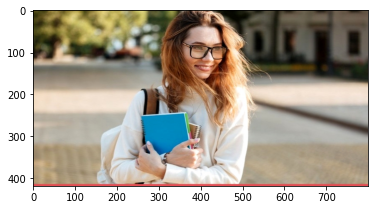

In [47]:
# Download data to test
if "person.jpg" not in os.listdir():
  !wget https://www.aconsciousrethink.com/wp-content/uploads/2019/05/reserved-person-line.jpg
  !mv reserved-person-line.jpg person.jpg

img = torchvision.io.read_image('person.jpg')
imgf = img.to(torch.float) / 255
plt.imshow(img.permute(1,2,0))
plt.show()

In [48]:
#@title COCO Utils

COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

In [49]:
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(pretrained=True)

In [63]:
model.eval()

predictions = model(imgf.unsqueeze(0))
print(predictions)

[{'boxes': tensor([[1.5502e+02, 2.5150e-01, 5.6679e+02, 4.1493e+02],
        [2.5876e+02, 2.3714e+02, 3.8545e+02, 3.5471e+02],
        [2.5907e+02, 2.3808e+02, 3.7612e+02, 3.5628e+02],
        [2.5971e+02, 2.3872e+02, 3.7334e+02, 3.5932e+02],
        [2.6306e+02, 2.4395e+02, 3.7360e+02, 3.6022e+02]],
       grad_fn=<StackBackward0>), 'labels': tensor([ 1, 73, 84, 47, 77]), 'scores': tensor([0.9999, 0.7645, 0.2119, 0.2069, 0.1218], grad_fn=<IndexBackward0>)}]


In [64]:
labels = [
  f"{COCO_INSTANCE_CATEGORY_NAMES[label]}:{'{:.2f}'.format(score)}" for label, score in zip(predictions[0]['labels'], predictions[0]['scores'])
]
bboxs = predictions[0]['boxes']
print(labels)
print(bboxs)

['person:1.00', 'laptop:0.76', 'book:0.21', 'cup:0.21', 'cell phone:0.12']
tensor([[1.5502e+02, 2.5150e-01, 5.6679e+02, 4.1493e+02],
        [2.5876e+02, 2.3714e+02, 3.8545e+02, 3.5471e+02],
        [2.5907e+02, 2.3808e+02, 3.7612e+02, 3.5628e+02],
        [2.5971e+02, 2.3872e+02, 3.7334e+02, 3.5932e+02],
        [2.6306e+02, 2.4395e+02, 3.7360e+02, 3.6022e+02]],
       grad_fn=<StackBackward0>)


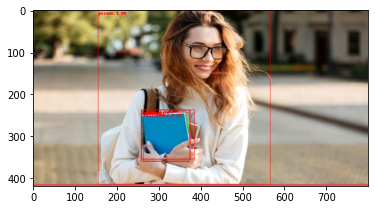

In [65]:
img_disp = torchvision.utils.draw_bounding_boxes(
  img,
  bboxs,
  labels,
  colors='red'
)
plt.imshow(img_disp.permute(1,2,0))
plt.show()

In [66]:
torch.hub.get_dir()

'/root/.cache/torch/hub'